In [ ]:
from google.colab import drive
import cv2
import numpy as np
from matplotlib import pyplot as plt

In [ ]:
drive.mount('/content/drive')
path = '/content/drive/My Drive/pcdpunya/kitten.jpg'

Mounted at /content/drive


(736, 736, 3)


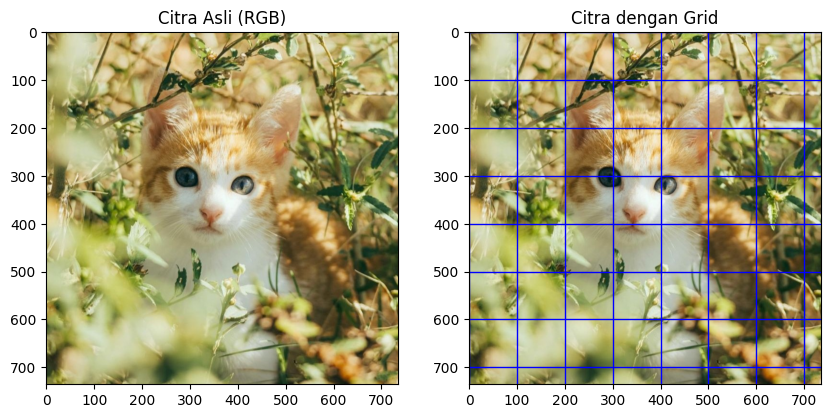

In [ ]:
# Membaca file RGB
i = cv2.imread(path)
i = cv2.cvtColor(i, cv2.COLOR_BGR2RGB)

print(i.shape)

# Menampilkan gambar RGB
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

axs[0].imshow(i)
axs[0].set_title('Citra Asli (RGB)')

axs[1].imshow(i)
axs[1].set_title('Citra dengan Grid')
axs[1].grid(True, color='blue', linewidth=1)

In [ ]:
print("Matriks citra RGB (5x10 piksel pertama):")
print(i[:5, :10])

Matriks citra RGB (10x10 piksel pertama):
[[[ 78  77  46]
  [ 85  84  53]
  [ 96  93  60]
  [ 95  91  56]
  [ 87  81  47]
  [ 86  78  41]
  [ 95  82  47]
  [ 99  85  46]
  [102  87  46]
  [106  87  44]]

 [[ 76  76  42]
  [ 82  82  48]
  [ 93  90  55]
  [ 99  95  60]
  [ 98  92  56]
  [ 95  85  49]
  [ 95  83  45]
  [ 96  83  41]
  [105  88  45]
  [107  89  43]]

 [[ 82  82  44]
  [ 85  85  47]
  [ 89  87  49]
  [ 96  92  54]
  [102  97  57]
  [102  93  52]
  [ 97  85  43]
  [ 94  81  37]
  [105  88  44]
  [108  90  42]]

 [[106 107  65]
  [103 104  62]
  [ 96  93  52]
  [ 90  85  45]
  [100  93  51]
  [107  98  55]
  [106  93  49]
  [102  88  41]
  [108  90  42]
  [112  92  41]]

 [[139 140  96]
  [134 135  91]
  [117 114  69]
  [ 95  91  46]
  [ 95  88  42]
  [109 101  54]
  [116 104  56]
  [112  98  49]
  [109  91  41]
  [115  95  42]]]


Text(0.5, 1.0, 'Histogram RGB')

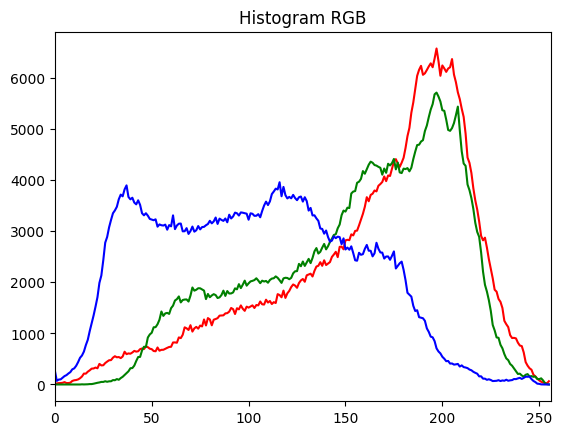

In [ ]:
# Histogram RGB
r = cv2.calcHist([i], [0], None, [256], [0, 256])
g = cv2.calcHist([i], [1], None, [256], [0, 256])
b = cv2.calcHist([i], [2], None, [256], [0, 256])

plt.plot(r, color='red')
plt.plot(g, color='green')
plt.plot(b, color='blue')
plt.xlim([0, 256])
plt.title('Histogram RGB')

In [ ]:
red = i[:, :, 0]
green = i[:, :, 1]
blue = i[:, :, 2]

merah = np.zeros_like(i)
hijau = np.zeros_like(i)
biru = np.zeros_like(i)

merah[:, :, 0] = red
hijau[:, :, 1] = green
biru[:, :, 2] = blue

(np.float64(-0.5), np.float64(735.5), np.float64(735.5), np.float64(-0.5))

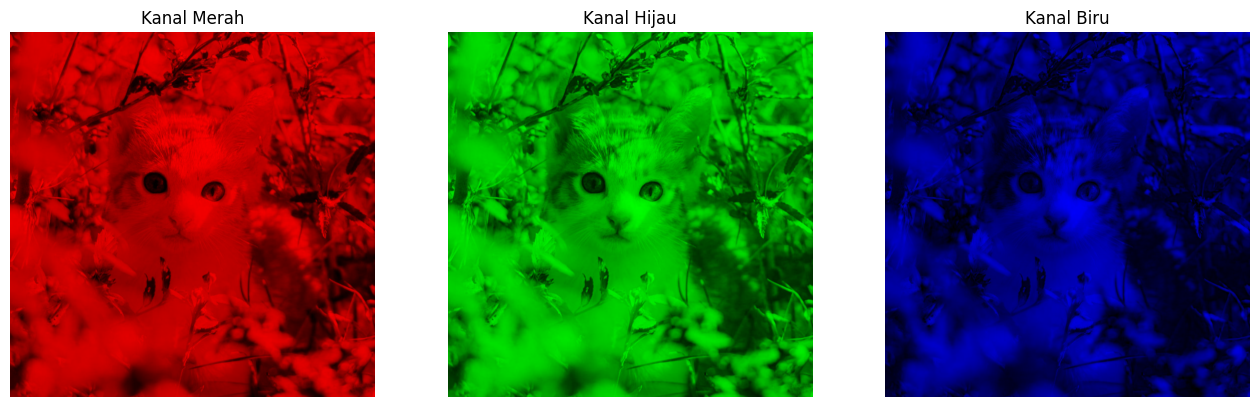

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(16, 8))

axs[0].imshow(merah)
axs[0].set_title('Kanal Merah')
axs[0].axis('off')

axs[1].imshow(hijau)
axs[1].set_title('Kanal Hijau')
axs[1].axis('off')

axs[2].imshow(biru)
axs[2].set_title('Kanal Biru')
axs[2].axis('off')

/tmp/ipython-input-521905877.py:3: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  axs[0].hist(red.ravel(), 256, [0, 256], color='red')
/tmp/ipython-input-521905877.py:6: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  axs[1].hist(green.ravel(), 256, [0, 256], color='green')
/tmp/ipython-input-521905877.py:9: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  axs[2].hist(blue.ravel(), 256, [0, 256], color='blue')


Text(0.5, 1.0, 'Histogram Kanal Biru')

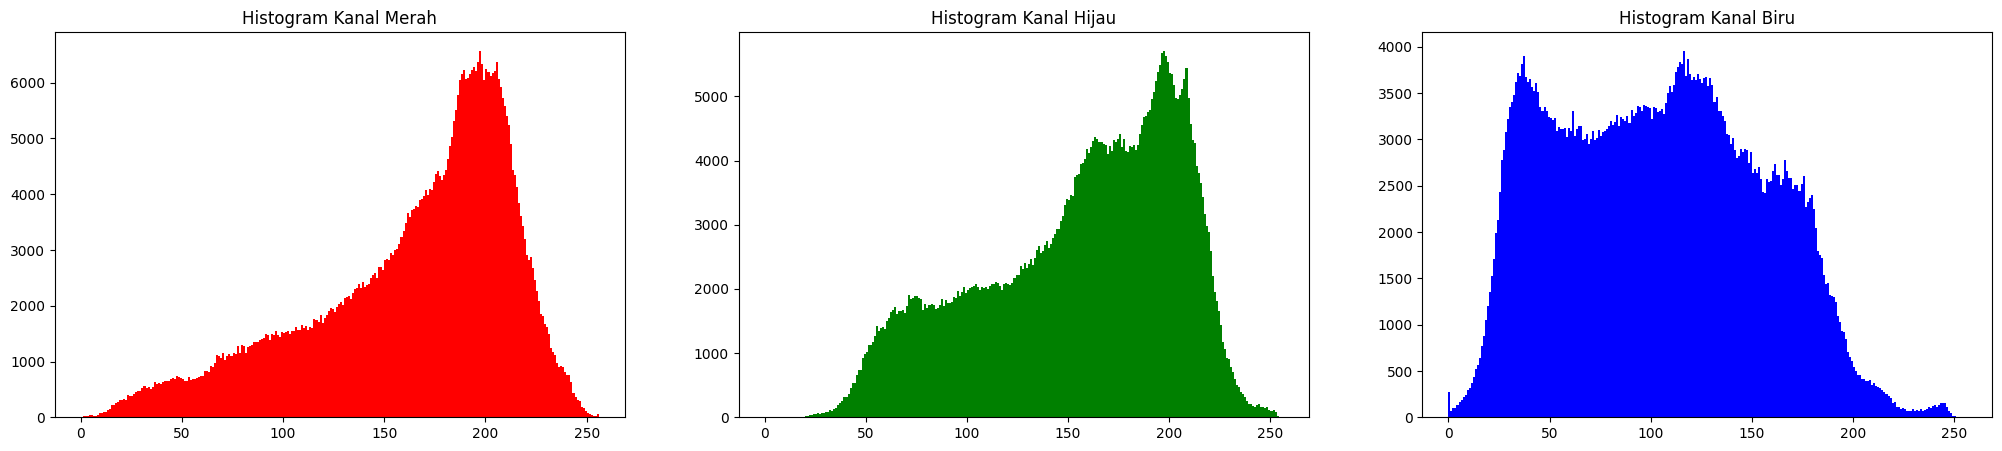

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(25, 5))

axs[0].hist(red.ravel(), 256, [0, 256], color='red')
axs[0].set_title('Histogram Kanal Merah')

axs[1].hist(green.ravel(), 256, [0, 256], color='green')
axs[1].set_title('Histogram Kanal Hijau')

axs[2].hist(blue.ravel(), 256, [0, 256], color='blue')
axs[2].set_title('Histogram Kanal Biru')

Text(0.5, 1.0, 'Histogram Grayscale')

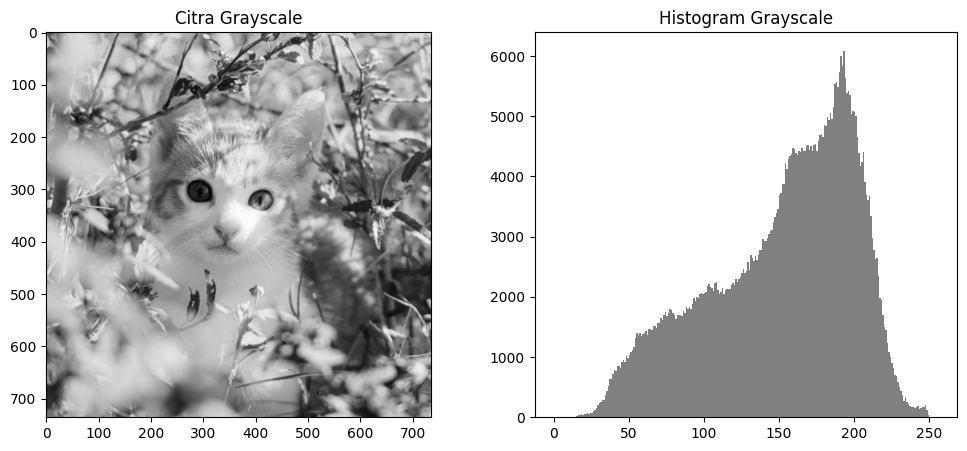

In [ ]:
gs = cv2.cvtColor(i, cv2.COLOR_RGB2GRAY)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].imshow(gs, cmap='gray')
axs[0].set_title('Citra Grayscale')

axs[1].hist(gs.ravel(), bins=256, range=[0, 256], color='gray')
axs[1].set_title('Histogram Grayscale')

Text(0.5, 1.0, 'Histogram Biner')

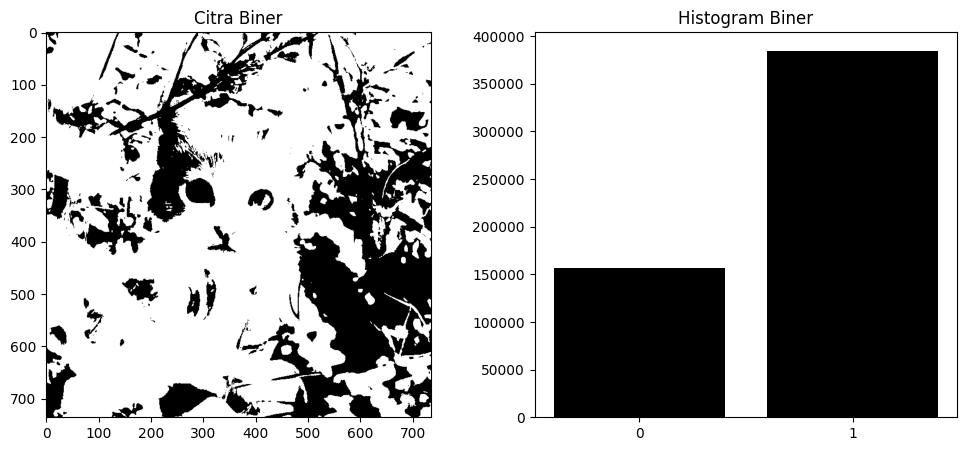

In [ ]:
_, bn = cv2.threshold(gs, 127, 255, cv2.THRESH_BINARY)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].imshow(bn, cmap='gray')
axs[0].set_title('Citra Biner')

bn_01 = (bn / 255).astype(int)
axs[1].hist(bn_01.ravel(), bins=[-0.5, 0.5, 1.5], color='black', rwidth=0.8)
axs[1].set_xticks([0, 1])
axs[1].set_title('Histogram Biner')

Text(0.5, 1.0, 'Histogram RGB High Brightness')

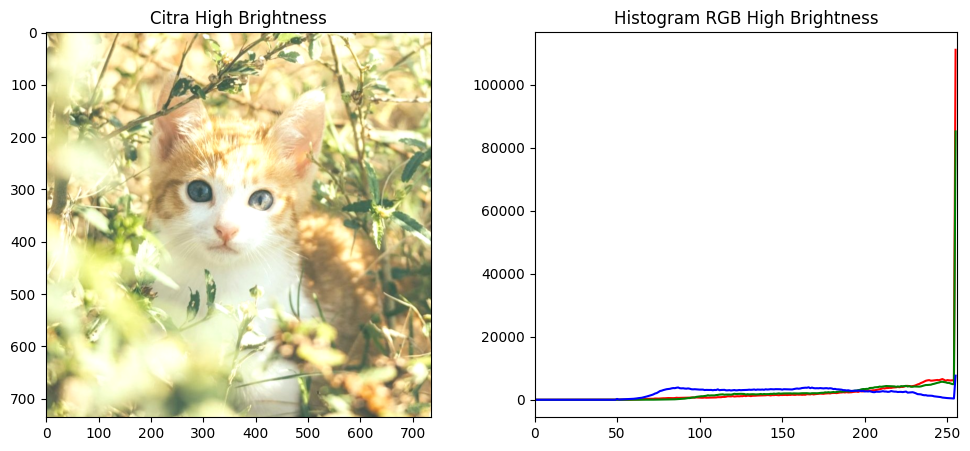

In [ ]:
beta=50

highbrightness = cv2.convertScaleAbs(i, beta=beta)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].imshow(highbrightness)
axs[0].set_title('Citra High Brightness')

r = cv2.calcHist([highbrightness], [0], None, [256], [0, 256])
g = cv2.calcHist([highbrightness], [1], None, [256], [0, 256])
b = cv2.calcHist([highbrightness], [2], None, [256], [0, 256])

axs[1].plot(r, color='red')
axs[1].plot(g, color='green')
axs[1].plot(b, color='blue')
axs[1].set_xlim([0, 256])
axs[1].set_title('Histogram RGB High Brightness')

Text(0.5, 1.0, 'Histogram RGB Low Brightness')

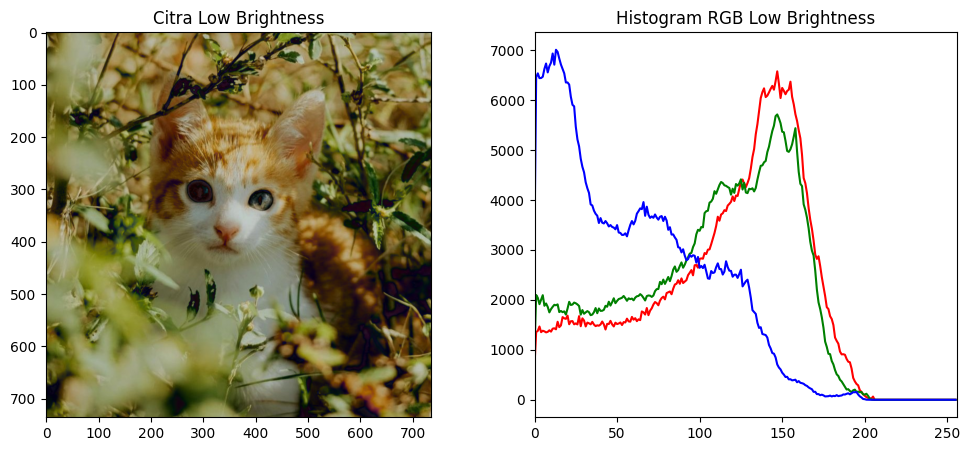

In [ ]:
beta=-50

lowbrightness = cv2.convertScaleAbs(i, beta=beta)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].imshow(lowbrightness)
axs[0].set_title('Citra Low Brightness')

r = cv2.calcHist([lowbrightness], [0], None, [256], [0, 256])
g = cv2.calcHist([lowbrightness], [1], None, [256], [0, 256])
b = cv2.calcHist([lowbrightness], [2], None, [256], [0, 256])

axs[1].plot(r, color='red')
axs[1].plot(g, color='green')
axs[1].plot(b, color='blue')
axs[1].set_xlim([0, 256])
axs[1].set_title('Histogram RGB Low Brightness')

Text(0.5, 1.0, 'Histogram RGB')

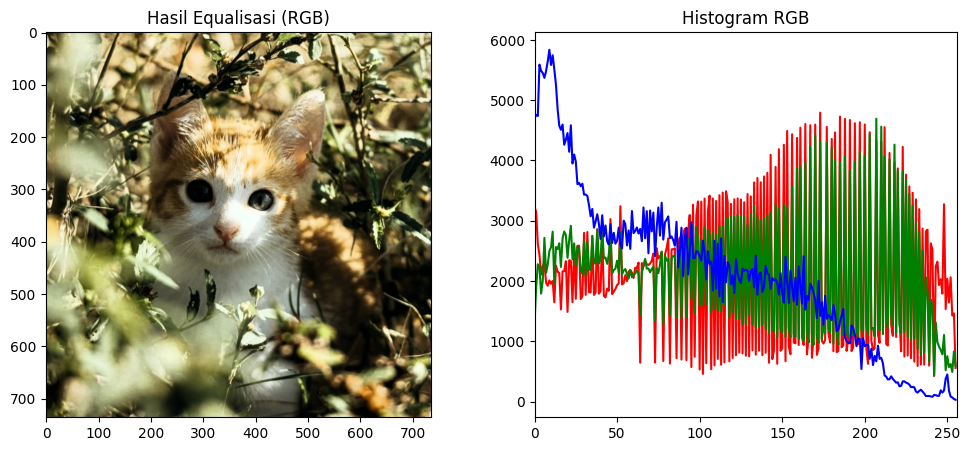

In [ ]:
hsv = cv2.cvtColor(i, cv2.COLOR_RGB2HSV)
h, s, v = cv2.split(hsv)
vequal = cv2.equalizeHist(v)
hsv_equal = cv2.merge([h, s, vequal])
img_hasil = cv2.cvtColor(hsv_equal, cv2.COLOR_HSV2RGB)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].imshow(img_hasil)
axs[0].set_title('Hasil Equalisasi (RGB)')

r = cv2.calcHist([img_hasil], [0], None, [256], [0, 256])
g = cv2.calcHist([img_hasil], [1], None, [256], [0, 256])
b = cv2.calcHist([img_hasil], [2], None, [256], [0, 256])

axs[1].plot(r, color='r')
axs[1].plot(g, color='g')
axs[1].plot(b, color='b')
axs[1].set_xlim([0, 256])
axs[1].set_title('Histogram RGB')

Text(0.5, 1.0, 'Histogram Equalisasi Grayscale')

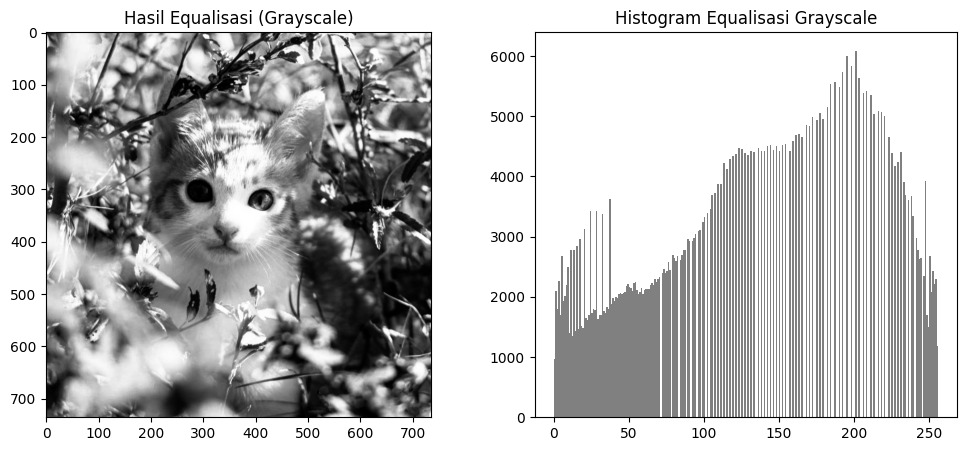

In [ ]:
ekual = cv2.equalizeHist(gs)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].imshow(ekual, cmap='gray')
axs[0].set_title('Hasil Equalisasi (Grayscale)')

axs[1].hist(ekual.ravel(), bins=256, range=[0, 256], color='gray')
axs[1].set_title('Histogram Equalisasi Grayscale')